# PARTIE A - Failure Prediction

## Objectif

L’objectif de cette partie est de prédire le score obtenu par un étudiant à un examen à partir de variables décrivant son profil, ses habitudes d’étude, ses conditions d’apprentissage et sa perception de l’examen.

Le score prédit permettra d’identifier les étudiants à risque, notamment ceux dont la note prédite est inférieure à 50, afin de leur proposer un accompagnement adapté.

## A1 - Importation des bibliothèques

On importe les bibliothèques nécessaires pour manipuler les données, réaliser les visualisations et préparer les futurs modèles de Machine Learning.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

## A2 - Chargement du dataset

On charge le fichier `train.csv` contenant les données étudiantes utilisées pour la prédiction du score d’examen.

In [2]:
df = pd.read_csv("../data/student_failure/train.csv")
df.head()


,id,age,genre,diplôme,heures_etude,assiduité_classe,accès_internet,heures_sommeil,qualité_sommeil,méthode_etude,évaluation_établissement,difficulté_examen,score_examen,heures_fête,taille_etudiant
0,0,21,male,Computer Science,7.91,98.8,NaN,4.9,average,online videos,low,easy,75.02,5,1.91
1,1,18,female,Law,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,49.03,4,1.89
2,2,20,female,Computer Science,4.68,92.6,NaN,5.8,poor,coaching,high,moderate,100.00,4,1.72
3,3,19,male,Computer Science,2.00,49.5,yes,8.3,average,group study,high,moderate,63.90,4,1.51
4,4,23,female,Business Management,7.65,86.9,yes,9.6,good,self-study,high,easy,100.00,2,1.94


## A3 - Compréhension générale du dataset

On vérifie la taille du dataset, les colonnes disponibles et les types de variables.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   id                        630000 non-null  int64  
 1   age                       630000 non-null  int64  
 2   genre                     630000 non-null  str    
 3   diplôme                   630000 non-null  str    
 4   heures_etude              611100 non-null  float64
 5   assiduité_classe          630000 non-null  float64
 6   accès_internet            567000 non-null  str    
 7   heures_sommeil            630000 non-null  float64
 8   qualité_sommeil           630000 non-null  str    
 9   méthode_etude             585900 non-null  str    
 10  évaluation_établissement  630000 non-null  str    
 11  difficulté_examen         630000 non-null  str    
 12  score_examen              630000 non-null  float64
 13  heures_fête               630000 non-null  int64  
 14 

In [4]:
df.shape

(630000, 15)

In [5]:
df.columns

Index(['id', 'age', 'genre', 'diplôme', 'heures_etude', 'assiduité_classe',
       'accès_internet', 'heures_sommeil', 'qualité_sommeil', 'méthode_etude',
       'évaluation_établissement', 'difficulté_examen', 'score_examen',
       'heures_fête', 'taille_etudiant'],
      dtype='str')

Le dataset contient 630 000 observations et 15 colonnes. Il s’agit donc d’un dataset volumineux, ce qui permet d’entraîner des modèles de Machine Learning avec une quantité importante d’exemples.

La variable cible est `score_examen`, qui représente la note obtenue par l’étudiant. Comme cette variable est numérique, le problème sera traité comme un problème de régression.

Le dataset contient :
- des variables numériques : âge, heures d’étude, assiduité, heures de sommeil, score, etc.
- des variables catégorielles : genre, diplôme, accès internet, méthode d’étude, difficulté de l’examen, etc.

On observe déjà la présence de valeurs manquantes dans certaines colonnes, notamment `heures_etude`, `acces_internet` et `methode_etude`. Ces valeurs devront être traitées dans la phase de preprocessing.

## A4 - Variable cible

La variable cible est `score_examen`.

C’est la note que le modèle devra prédire. Comme cette variable est numérique, le problème est d’abord traité comme un problème de régression.

In [6]:
target = "score_examen"

df[target].describe()

count    630000.000000
mean         63.406789
std          18.950840
min          12.600000
25%          49.600000
50%          63.620000
75%          77.300000
max         100.000000
Name: score_examen, dtype: float64

## A5 - Types de variables

On sépare les variables numériques et catégorielles afin de mieux préparer l’analyse exploratoire et le prétraitement.

In [7]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

numeric_cols, categorical_cols

C:\Users\yayal\AppData\Local\Temp\ipykernel_9164\3105708109.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()


(['id',
  'age',
  'heures_etude',
  'assiduité_classe',
  'heures_sommeil',
  'score_examen',
  'heures_fête',
  'taille_etudiant'],
 ['genre',
  'diplôme',
  'accès_internet',
  'qualité_sommeil',
  'méthode_etude',
  'évaluation_établissement',
  'difficulté_examen'])

In [8]:
print("Variables numériques :", numeric_cols)
print("Variables catégorielles :", categorical_cols)

Variables numériques : ['id', 'age', 'heures_etude', 'assiduité_classe', 'heures_sommeil', 'score_examen', 'heures_fête', 'taille_etudiant']
Variables catégorielles : ['genre', 'diplôme', 'accès_internet', 'qualité_sommeil', 'méthode_etude', 'évaluation_établissement', 'difficulté_examen']


## A6 - Analyse des valeurs manquantes

On vérifie quelles colonnes contiennent des valeurs manquantes. Cette étape est essentielle car les modèles de Machine Learning ne peuvent pas toujours gérer directement des données incomplètes.

In [9]:
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percent": missing_percent
}).sort_values(by="missing_percent", ascending=False)

missing_table

,missing_count,missing_percent
accès_internet,63000,10.0
méthode_etude,44100,7.0
heures_etude,18900,3.0
genre,0,0.0
age,0,0.0
diplôme,0,0.0
id,0,0.0
assiduité_classe,0,0.0
heures_sommeil,0,0.0
qualité_sommeil,0,0.0


In [10]:
df.shape
df.info()
missing_table

<class 'pandas.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   id                        630000 non-null  int64  
 1   age                       630000 non-null  int64  
 2   genre                     630000 non-null  str    
 3   diplôme                   630000 non-null  str    
 4   heures_etude              611100 non-null  float64
 5   assiduité_classe          630000 non-null  float64
 6   accès_internet            567000 non-null  str    
 7   heures_sommeil            630000 non-null  float64
 8   qualité_sommeil           630000 non-null  str    
 9   méthode_etude             585900 non-null  str    
 10  évaluation_établissement  630000 non-null  str    
 11  difficulté_examen         630000 non-null  str    
 12  score_examen              630000 non-null  float64
 13  heures_fête               630000 non-null  int64  
 14 

,missing_count,missing_percent
accès_internet,63000,10.0
méthode_etude,44100,7.0
heures_etude,18900,3.0
genre,0,0.0
age,0,0.0
diplôme,0,0.0
id,0,0.0
assiduité_classe,0,0.0
heures_sommeil,0,0.0
qualité_sommeil,0,0.0


### Interprétation des valeurs manquantes

On observe que certaines variables contiennent des valeurs manquantes :

- `acces_internet` : 10%
- `methode_etude` : 7%
- `heures_etude` : 3%

Ces variables devront être traitées lors du preprocessing.

Le fait que certaines variables importantes comme `heures_etude` contiennent des valeurs manquantes peut influencer la qualité des prédictions si elles ne sont pas correctement traitées.

Les autres variables ne présentent pas de valeurs manquantes, ce qui simplifie l’analyse.

## A7 - Distribution de la variable cible

On analyse la distribution du score d’examen afin de comprendre comment les notes sont réparties.

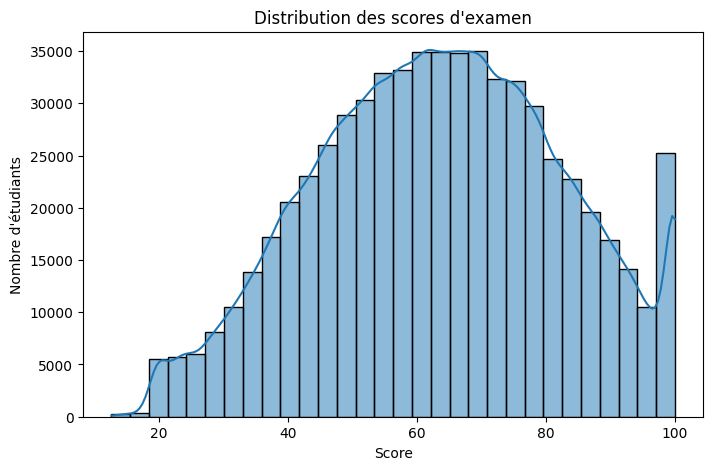

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df["score_examen"], bins=30, kde=True)

plt.title("Distribution des scores d'examen")
plt.xlabel("Score")
plt.ylabel("Nombre d'étudiants")

plt.show()

### Interprétation de la distribution des scores

La distribution des scores d’examen présente une forme globalement gaussienne (en cloche), centrée autour d’une moyenne située entre 60 et 70.

Cela indique que :
- la majorité des étudiants obtiennent des résultats moyens,
- peu d’étudiants ont des scores très faibles ou très élevés,
- la distribution est relativement équilibrée.

On observe également une accumulation de valeurs proches de 100, ce qui pourrait indiquer un effet de plafond (beaucoup d’étudiants atteignent le maximum).

Cette distribution est favorable pour l’entraînement de modèles de régression, car elle ne présente pas de déséquilibre extrême.

On remarque une légère concentration de valeurs proches de 100, ce qui pourrait suggérer :
- soit des étudiants très performants,
- soit un effet de saturation du score maximum.

Cela devra être pris en compte lors de l’évaluation du modèle, car il pourrait être plus difficile de prédire précisément les valeurs proches des extrêmes.

## A8 - Relation entre heures d'étude et score

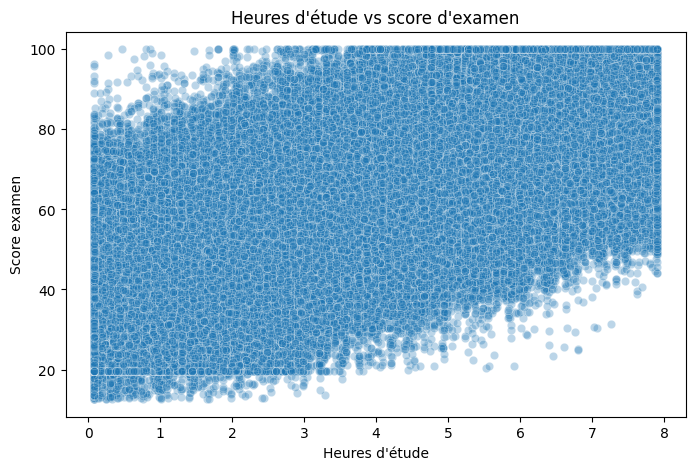

In [12]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["heures_etude"], y=df["score_examen"], alpha=0.3)

plt.title("Heures d'étude vs score d'examen")
plt.xlabel("Heures d'étude")
plt.ylabel("Score examen")

plt.show()

### Interprétation

Le graphique montre une relation globalement positive entre le nombre d’heures d’étude et le score obtenu à l’examen.

Cependant, la dispersion des points est très importante : pour un même nombre d’heures d’étude, les scores peuvent varier fortement.

Cela indique que :
- les heures d’étude ont une influence sur la réussite,
- mais ne suffisent pas à expliquer entièrement la performance,
- d’autres variables jouent un rôle important (assiduité, sommeil, méthode d’étude, etc.).

Ainsi, le modèle devra prendre en compte plusieurs variables pour être performant.

On observe également que les scores semblent plafonnés à 100, ce qui confirme l’existence d’un effet de saturation.

De plus, même avec un faible nombre d’heures d’étude, certains étudiants obtiennent de bons résultats, ce qui suggère l’influence d’autres facteurs comme :
- la qualité de l’étude,
- les capacités individuelles,
- ou les conditions d’apprentissage.

Du point de vue de la sécurité, la variable `heures_etude` est déclarative et donc potentiellement manipulable.

Cependant, étant donné la dispersion observée, modifier cette variable seule ne garantit pas une amélioration significative du score prédit.

Cela limite partiellement le risque de manipulation, mais ne l’élimine pas complètement.

## A9 - Relation entre assiduité en classe et score

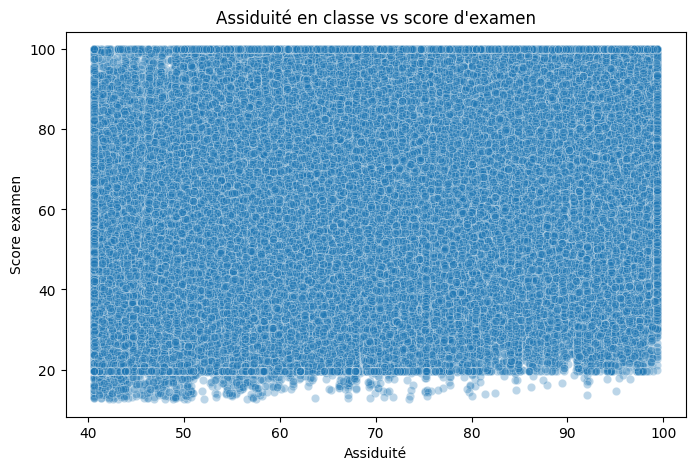

In [13]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["assiduité_classe"], y=df["score_examen"], alpha=0.3)

plt.title("Assiduité en classe vs score d'examen")
plt.xlabel("Assiduité")
plt.ylabel("Score examen")

plt.show()

### Interprétation

Le graphique ne montre pas de relation claire entre l’assiduité en classe et le score d’examen.

Contrairement à l’intuition, une assiduité élevée ne garantit pas un score élevé, et une assiduité plus faible n’implique pas nécessairement un mauvais résultat.

Cela suggère que :
- l’assiduité seule n’est pas un facteur déterminant,
- d’autres variables jouent un rôle plus important dans la réussite.

Cette observation sera confirmée ou non lors de l’analyse des corrélations et de l’entraînement des modèles.

En comparant avec le graphique précédent (heures d’étude), on observe que :

- les heures d’étude présentent une tendance positive avec le score,
- tandis que l’assiduité en classe ne montre pas de relation claire.

Cela suggère que le travail personnel pourrait avoir un impact plus important que la simple présence en classe.

Du point de vue de la sécurité, l’assiduité en classe peut être considérée comme une variable plus fiable que les heures d’étude, car elle est généralement mesurée par l’établissement.

Cependant, étant donné son faible lien apparent avec le score, manipuler cette variable aurait probablement un impact limité sur la prédiction du modèle.

## A10 - Variable catégorielle

In [14]:
df.columns.tolist()

['id',
 'age',
 'genre',
 'diplôme',
 'heures_etude',
 'assiduité_classe',
 'accès_internet',
 'heures_sommeil',
 'qualité_sommeil',
 'méthode_etude',
 'évaluation_établissement',
 'difficulté_examen',
 'score_examen',
 'heures_fête',
 'taille_etudiant']

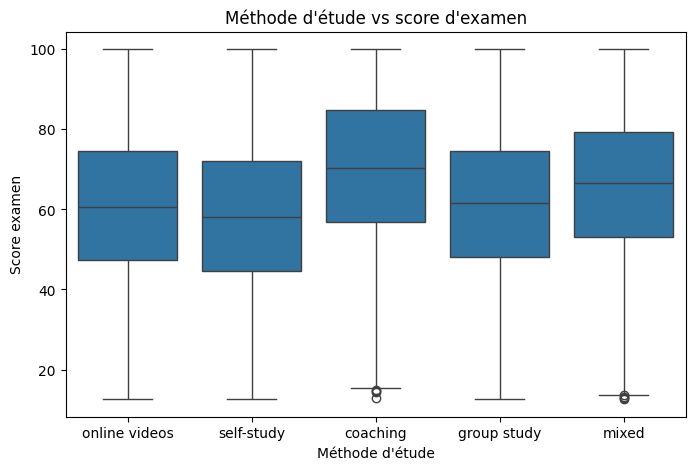

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["méthode_etude"], y=df["score_examen"])

plt.title("Méthode d'étude vs score d'examen")
plt.xlabel("Méthode d'étude")
plt.ylabel("Score examen")

plt.show()

### Interprétation

Le boxplot met en évidence des différences entre les méthodes d’étude.

On observe que :
- les étudiants utilisant le coaching obtiennent en moyenne les meilleurs résultats,
- les méthodes mixtes (mixed) donnent également de bons résultats,
- le self-study semble être la méthode la moins performante en moyenne.

Cependant, la dispersion des scores est importante pour toutes les méthodes :
- certaines personnes réussissent très bien même en self-study,
- d’autres échouent malgré des méthodes plus encadrées.

Cela montre que la méthode d’étude influence le score, mais ne suffit pas à expliquer à elle seule la performance.

On remarque que les méthodes impliquant un encadrement (coaching, group study) tendent à produire de meilleurs résultats.

Cela suggère que l’accompagnement et l’interaction peuvent jouer un rôle important dans la réussite académique.

Du point de vue de la sécurité, la variable `methode_etude` est déclarative.

Un étudiant pourrait mentir sur sa méthode d’étude pour influencer la prédiction du modèle.

Étant donné que cette variable a un impact visible sur les scores, cela représente un risque réel de manipulation du modèle.

Il sera donc important de vérifier la robustesse du modèle face à ce type de modification.

## A11 - Corrélation (vision globale)

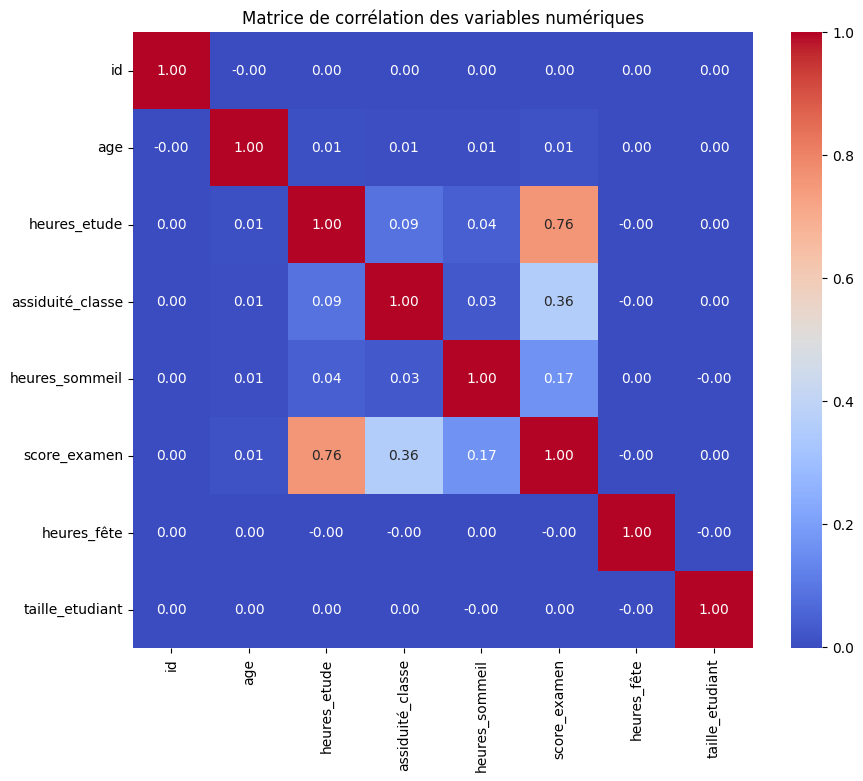

In [16]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Matrice de corrélation des variables numériques")

plt.show()

### Interprétation de la matrice de corrélation

La matrice de corrélation met en évidence les relations entre les variables numériques et le score d’examen.

On observe que :
- `heures_etude` présente une corrélation forte (0.76) avec le score, ce qui en fait la variable la plus influente,
- `assiduité_classe` a une corrélation modérée (0.36),
- `heures_sommeil` a une corrélation faible (0.17),
- les autres variables numériques ont une corrélation proche de 0.

Ces résultats confirment les observations faites lors de l’analyse graphique.

Ainsi, le temps d’étude apparaît comme le facteur principal de réussite dans ce dataset.

On remarque que certaines variables comme `heures_fête` ou `taille_etudiant` n’ont aucun lien avec le score.

Cela suggère qu’elles n’apporteront pas d’information utile au modèle et pourraient être ignorées lors de l’entraînement.

Du point de vue de la sécurité, la variable `heures_etude` est à la fois très influente et déclarative.

Cela signifie qu’un étudiant pourrait manipuler cette variable pour influencer la prédiction du modèle.

Par exemple, en augmentant artificiellement son nombre d’heures d’étude, un étudiant pourrait faire croire au modèle qu’il a un meilleur niveau qu’en réalité.

Cela représente un risque important de manipulation du système.

## A12 - Sélection des variables

Dans cette étape, on sélectionne les variables à utiliser pour le modèle.

Certaines variables sont supprimées :
- `id`, car il s’agit d’un identifiant sans valeur prédictive.

Les autres variables sont conservées car :
- certaines présentent une corrélation élevée avec la variable cible (ex: `heures_etude`),
- d’autres peuvent avoir des effets non linéaires ou combinés,
- les variables catégorielles peuvent contenir des informations importantes.

Ainsi, on choisit de conserver la majorité des variables, sauf celles qui sont clairement inutiles.

Même si certaines variables semblent peu corrélées avec le score (comme `heures_fête`), elles sont conservées dans un premier temps.

En effet, certains modèles (comme Random Forest) peuvent exploiter des relations complexes que la corrélation linéaire ne permet pas de détecter.

On note que certaines variables importantes comme `heures_etude` ou `methode_etude` sont déclaratives.

Cela signifie qu’elles peuvent être manipulées par les étudiants, ce qui représente un risque pour la fiabilité du modèle.

Cette problématique sera étudiée plus en détail dans la partie sécurité.

In [17]:
# Suppression de la variable inutile
df_model = df.drop(columns=["id"])

df_model.head()

,age,genre,diplôme,heures_etude,assiduité_classe,accès_internet,heures_sommeil,qualité_sommeil,méthode_etude,évaluation_établissement,difficulté_examen,score_examen,heures_fête,taille_etudiant
0,21,male,Computer Science,7.91,98.8,NaN,4.9,average,online videos,low,easy,75.02,5,1.91
1,18,female,Law,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,49.03,4,1.89
2,20,female,Computer Science,4.68,92.6,NaN,5.8,poor,coaching,high,moderate,100.00,4,1.72
3,19,male,Computer Science,2.00,49.5,yes,8.3,average,group study,high,moderate,63.90,4,1.51
4,23,female,Business Management,7.65,86.9,yes,9.6,good,self-study,high,easy,100.00,2,1.94


## A13 - Prétraitement des données

Avant d’entraîner les modèles de Machine Learning, il est nécessaire de préparer les données.

Le dataset contient :
- des variables numériques,
- des variables catégorielles,
- des valeurs manquantes.

Les modèles de Machine Learning ne peuvent pas traiter directement ces données brutes.

Le preprocessing permet donc de :
- remplacer les valeurs manquantes,
- transformer les variables catégorielles en variables numériques,
- normaliser les variables numériques.

Ces transformations sont regroupées dans un pipeline afin d’automatiser le processus et d’éviter les erreurs.

In [19]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# séparation des types de variables
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object", "string"]).columns

# traitement des variables numériques
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),   # remplace les NaN
    ("scaler", StandardScaler())                     # normalisation
])

# traitement des variables catégorielles
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),  # remplace les NaN
    ("encoder", OneHotEncoder(handle_unknown="ignore"))    # transforme texte → nombres
])

# combinaison des deux
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

preprocessor

NameError: name 'X' is not defined

### Interprétation

Le preprocessing permet de transformer les données brutes en données exploitables par les modèles de Machine Learning.

Dans ce projet, deux types de variables sont traités différemment :

- Les variables numériques :
  - Les valeurs manquantes sont remplacées par la médiane,
  - Les données sont normalisées afin d’éviter que certaines variables dominent les autres en raison de leur échelle.

- Les variables catégorielles :
  - Les valeurs manquantes sont remplacées par la valeur la plus fréquente,
  - Les variables sont transformées en variables numériques grâce à un encodage One-Hot.

L’ensemble de ces transformations est regroupé dans un pipeline, ce qui permet d’appliquer automatiquement les mêmes étapes aux données d’entraînement et de test.

Cette étape est essentielle pour garantir le bon fonctionnement et la robustesse des modèles.

On note que certaines variables importantes comme `heures_etude` ou `methode_etude` sont déclaratives.

Le preprocessing permet de les rendre exploitables par le modèle, mais ne corrige pas le fait qu’elles puissent être manipulées.

Cela représente un risque du point de vue de la sécurité, qui sera étudié plus en détail dans la suite du projet.

## A14 - Modèle baseline

Un modèle baseline est utilisé comme référence minimale.

Dans ce cas, on utilise un modèle très simple qui prédit toujours la moyenne des scores d’examen.

Ce modèle permet de comparer les performances des modèles plus avancés.

Un bon modèle doit obtenir de meilleures performances que cette baseline.

In [ ]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# pipeline avec preprocessing + modèle
baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DummyRegressor(strategy="mean"))
])

# entraînement
baseline_model.fit(X_train, y_train)

# prédiction
y_pred_baseline = baseline_model.predict(X_test)

# métriques
mae_baseline = mean_absolute_error(y_test, y_pred_baseline)
rmse_baseline = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
r2_baseline = r2_score(y_test, y_pred_baseline)

mae_baseline, rmse_baseline, r2_baseline

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_baseline, alpha=0.3)
plt.plot([0, 100], [0, 100], "r--")
plt.xlabel("Score réel")
plt.ylabel("Score prédit")
plt.title("Baseline : score réel vs score prédit")
plt.show()

### Interprétation

Le modèle baseline prédit toujours la moyenne des scores.

Les performances obtenues sont les suivantes :
- MAE ≈ 15.6
- RMSE ≈ 18.9
- R² ≈ 0

Cela signifie que le modèle n’explique pas la variance des données et ne prend en compte aucune information des variables explicatives.

Ces résultats servent de référence minimale.

Les modèles plus avancés devront améliorer ces performances.

Le score R² proche de 0 confirme que le modèle baseline n’apporte aucune information utile.

Il est donc essentiel d’utiliser des modèles capables d’exploiter les relations entre les variables.

## A15 - Modèle 1 : Régression linéaire

La régression linéaire est utilisée comme premier modèle réel.

Contrairement à la baseline, elle utilise les variables explicatives pour prédire le score d’examen.

Ce modèle est simple, rapide et interprétable.

In [ ]:
from sklearn.linear_model import LinearRegression

linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)

mae_linear, rmse_linear, r2_linear

In [ ]:
plt.figure(figsize=(6,6))
plt.hexbin(y_test, y_pred_linear, gridsize=50, cmap="Blues")
plt.plot([0, 100], [0, 100], "r--")
plt.colorbar(label="Densité")
plt.xlabel("Score réel")
plt.ylabel("Score prédit")
plt.title("Régression linéaire (densité)")
plt.show()

In [ ]:
residuals = y_test - y_pred_linear

plt.figure(figsize=(6,4))
plt.scatter(y_pred_linear, residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Score prédit")
plt.ylabel("Erreur (réel - prédit)")
plt.title("Résidus - Régression linéaire")
plt.show()

### Interprétation

La régression linéaire améliore fortement les performances par rapport au modèle baseline.

Les résultats obtenus sont :
- MAE ≈ 7.38
- RMSE ≈ 9.31
- R² ≈ 0.76

Cela signifie que le modèle explique environ 76% de la variance du score d’examen.

L’erreur moyenne est réduite de moitié par rapport à la baseline, ce qui montre que le modèle exploite efficacement les relations entre les variables.

La régression linéaire constitue donc un bon point de départ pour la prédiction du score.

Cependant, la régression linéaire suppose des relations linéaires entre les variables.

Or, certaines relations peuvent être plus complexes.

Il sera donc intéressant de tester des modèles plus avancés capables de capturer des relations non linéaires.

## A16 - Modèle 2 : Random Forest

Le modèle Random Forest est utilisé comme modèle plus avancé.

Contrairement à la régression linéaire, il est capable de capturer des relations non linéaires entre les variables.

Il repose sur un ensemble d’arbres de décision, ce qui le rend plus robuste et plus performant dans de nombreux cas.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=100, random_state=42))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

mae_rf, rmse_rf, r2_rf

In [ ]:
y_test_np = np.array(y_test).ravel()
y_pred_rf_np = np.array(y_pred_rf).ravel()

plt.figure(figsize=(6,6))
plt.scatter(y_test_np, y_pred_rf_np, alpha=0.1)
plt.plot([0, 100], [0, 100], "r--")
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.xlabel("Score réel")
plt.ylabel("Score prédit")
plt.title("Random Forest : score réel vs score prédit")
plt.show()

In [ ]:
from sklearn.neural_network import MLPRegressor

mlp_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        max_iter=200,
        random_state=42
    ))
])

mlp_model.fit(X_train, y_train)

y_pred_mlp = mlp_model.predict(X_test)

mae_mlp = mean_absolute_error(y_test, y_pred_mlp)
rmse_mlp = np.sqrt(mean_squared_error(y_test, y_pred_mlp))
r2_mlp = r2_score(y_test, y_pred_mlp)

mae_mlp, rmse_mlp, r2_mlp

## A17 - Comparaison des modèles

Dans cette section, on compare les performances des différents modèles :

- Baseline (Dummy Regressor)
- Régression linéaire
- Random Forest

Les métriques utilisées sont :
- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)
- R² (coefficient de détermination)

L’objectif est d’identifier le modèle le plus performant.

In [ ]:
results = pd.DataFrame({
    "Model": ["Baseline", "Linear Regression", "Random Forest", "MLP"],
    "MAE": [mae_baseline, mae_linear, mae_rf, mae_mlp],
    "RMSE": [rmse_baseline, rmse_linear, rmse_rf, rmse_mlp],
    "R2": [r2_baseline, r2_linear, r2_rf, r2_mlp]
})

results

In [ ]:
results.sort_values(by="MAE")

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(data=results, x="Model", y="MAE")
plt.title("Comparaison des modèles - MAE")
plt.ylabel("MAE")
plt.show()

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(data=results, x="Model", y="RMSE")
plt.title("Comparaison des modèles - RMSE")
plt.ylabel("RMSE")
plt.show()

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(data=results, x="Model", y="R2")
plt.title("Comparaison des modèles - R²")
plt.ylabel("R²")
plt.show()

In [ ]:
results_melted = results.melt(id_vars="Model", var_name="Metric", value_name="Value")

plt.figure(figsize=(10,6))
sns.barplot(data=results_melted, x="Model", y="Value", hue="Metric")
plt.title("Comparaison globale des modèles")
plt.show()

### Interprétation

Les résultats montrent une nette amélioration entre la baseline et les modèles entraînés.

La régression linéaire obtient les meilleures performances :
- MAE ≈ 7.38
- RMSE ≈ 9.31
- R² ≈ 0.76

Le modèle Random Forest donne des résultats similaires mais légèrement moins bons.

Cela indique que les relations entre les variables et le score sont principalement linéaires.

La régression linéaire est donc le modèle le plus adapté dans ce cas.

Le modèle Random Forest, bien que plus complexe, n’apporte pas d’amélioration significative.

Cela montre que :
- augmenter la complexité du modèle ne garantit pas de meilleures performances,
- il est essentiel de comparer plusieurs modèles.

La régression linéaire présente aussi l’avantage d’être plus rapide et plus interprétable.

## A18 - Overfitting / Underfitting

In [ ]:
# prédictions sur train
y_train_pred_linear = linear_model.predict(X_train)
y_train_pred_rf = rf_model.predict(X_train)

# erreurs train
mae_train_linear = mean_absolute_error(y_train, y_train_pred_linear)
mae_train_rf = mean_absolute_error(y_train, y_train_pred_rf)

mae_train_linear, mae_train_rf

### Interprétation

Les résultats montrent une différence importante entre les performances sur les données d’entraînement et celles sur les données de test pour le modèle Random Forest.

En effet :
- MAE train ≈ 2.81
- MAE test ≈ 7.54

Cette différence indique un phénomène de surapprentissage (overfitting).

Le modèle Random Forest apprend très bien les données d’entraînement, mais ne parvient pas à généraliser correctement sur de nouvelles données.

À l’inverse, la régression linéaire présente des performances similaires entre le train et le test, ce qui indique une meilleure capacité de généralisation.

Cela confirme que, dans ce cas, un modèle simple est plus adapté.

Ce phénomène montre qu’un modèle plus complexe n’est pas nécessairement meilleur.

Il est important de trouver un équilibre entre complexité et capacité de généralisation.

## A19 - SÉCURITÉ

In [ ]:
study_values = list(range(0, 21))
predictions = []

sample_security = X_test.iloc[[0]].copy()

for h in study_values:
    sample_modified = sample_security.copy()
    sample_modified["heures_etude"] = h
    predictions.append(linear_model.predict(sample_modified)[0])

plt.figure(figsize=(8,5))
plt.plot(study_values, predictions, marker="o")
plt.axhline(50, linestyle="--")
plt.xlabel("Heures d'étude déclarées")
plt.ylabel("Score prédit")
plt.title("Impact d'une manipulation de heures_etude")
plt.show()

### Interprétation sécurité

La prédiction originale pour l’étudiant sélectionné est d’environ **76.84**.

En modifiant uniquement la variable `heures_etude`, on obtient :

| Valeur de `heures_etude` | Score prédit |
|---|---|
| 0 | 36.92 |
| 7 | 76.61 |
| 8 | 82.28 |
| 20 | 150.34 |

On observe que la prédiction varie fortement lorsque `heures_etude` est modifiée.

Une modification réaliste de 7 à 8 heures augmente déjà la prédiction d’environ **+5.7 points**.  
Une valeur extrême comme 20 heures produit une prédiction irréaliste supérieure à 100, ce qui montre que le modèle linéaire peut extrapoler en dehors des limites réalistes.

Cela confirme que le modèle est vulnérable à la manipulation d’une variable déclarative importante.

Dans un système réel, il faudrait limiter les valeurs acceptées, vérifier les données déclaratives, ou utiliser des variables plus fiables mesurées par l’établissement.

## A20 - BIAS

### Genre

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["genre"], y=df["score_examen"])

plt.title("Genre vs score examen")
plt.show()

### Diplôme

In [ ]:
plt.figure(figsize=(16,6))
sns.boxplot(x=df["diplôme"], y=df["score_examen"])

plt.title("Diplôme vs score examen")
plt.show()

### Interprétation

L’analyse du biais a été réalisée sur les variables `genre` et `diplome`.

Concernant le genre :
- les distributions des scores sont très similaires entre les hommes et les femmes,
- la médiane est légèrement plus élevée pour les femmes, mais la différence reste faible.

Concernant le diplôme :
- aucune différence significative n’est observée entre les différentes catégories,
- les médianes et la dispersion sont très proches.

Ces résultats suggèrent que ces variables n’introduisent pas de biais important dans le modèle.

Le modèle semble donc relativement équitable vis-à-vis de ces caractéristiques.

Même si aucun biais important n’est observé, l’utilisation de variables comme le genre peut poser des questions éthiques.

Dans un système réel, il pourrait être pertinent d’exclure certaines variables sensibles afin de garantir l’équité du modèle.

## A21 - Explainability

In [ ]:
# récupérer les coefficients du modèle linéaire
model = linear_model.named_steps["model"]

coefficients = model.coef_

# récupérer les noms des features après preprocessing
feature_names = linear_model.named_steps["preprocessor"].get_feature_names_out()

# créer tableau
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": coefficients
})

# trier
importance_df = importance_df.sort_values(by="importance", ascending=False)

importance_df.head(10)

### Interprétation

L’analyse des coefficients du modèle de régression linéaire permet d’identifier les variables les plus influentes.

On observe que :
- `heures_etude` est de loin la variable la plus importante,
- `assiduité_classe` a également un impact significatif,
- certaines variables catégorielles comme `methode_etude_coaching` ou `qualité_sommeil_good` influencent positivement le score.

Ces résultats sont cohérents avec l’analyse exploratoire réalisée précédemment.

Ils montrent que la performance des étudiants dépend principalement de leur investissement personnel et de leur environnement d’apprentissage.

L’explicabilité du modèle permet également d’identifier des variables sensibles du point de vue de la sécurité.

Par exemple, `heures_etude` et `methode_etude` sont à la fois très influentes et déclaratives, ce qui les rend vulnérables à la manipulation.

Cela confirme les observations faites dans la partie sécurité.